In [17]:
!pip install opencv-python -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    TimeDistributed,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
#step-datasetpath
DATASET_PATH = "/content/drive/MyDrive/ucf101_top5/Dataset"

print(os.listdir(DATASET_PATH))

# IMAGE SIZE
IMG_SIZE = 96

# NUMBER OF FRAMES PER VIDEO
SEQUENCE_LENGTH = 15

# YOUR CLASSES
CLASSES_LIST = [
    "CricketShot",
    "PlayingCello",
    "PlayingGuitar",
    "Punch",
    "ShavingBeard"
]

print("Classes Loaded Successfully")

['Punch', 'PlayingGuitar', 'CricketShot', 'ShavingBeard', 'PlayingCello']
Classes Loaded Successfully


In [20]:
def extract_frames(video_path):

    frames = []

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    skip_frames = max(total_frames // SEQUENCE_LENGTH, 1)

    for i in range(SEQUENCE_LENGTH):

        frame_id = i * skip_frames

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

        success, frame = cap.read()

        if not success:
            break

        # Resize Frame
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

        # Normalize
        frame = frame / 255.0

        frames.append(frame)

    cap.release()

    return frames

In [21]:
# ============================================================
# STEP 5 — CREATE DATASET (RAM OPTIMIZED VERSION)
# ============================================================

features = []
labels = []

# VALID VIDEO FORMATS
video_extensions = ('.avi', '.mp4', '.mov')

for class_name in CLASSES_LIST:

    print(f"\nProcessing Class: {class_name}")

    class_path = os.path.join(DATASET_PATH, class_name)

    # GET ONLY VIDEO FILES
    video_files = [
        file for file in os.listdir(class_path)
        if file.endswith(video_extensions)
    ]

    # LIMIT VIDEOS PER CLASS (RAM OPTIMIZATION)
    video_files = video_files[:30]

    print(f"Videos Used: {len(video_files)}")

    for file_name in video_files:

        video_path = os.path.join(class_path, file_name)

        # EXTRACT FRAMES
        frames = extract_frames(video_path)

        # ONLY USE COMPLETE FRAME SEQUENCES
        if len(frames) == SEQUENCE_LENGTH:

            features.append(frames)
            labels.append(class_name)

print("\nDataset Creation Completed")

# CONVERT TO NUMPY ARRAYS
features = np.asarray(features)
labels = np.asarray(labels)

print("Feature Shape:", features.shape)
print("Labels Shape:", labels.shape)


Processing Class: CricketShot
Videos Used: 30

Processing Class: PlayingCello
Videos Used: 30

Processing Class: PlayingGuitar
Videos Used: 30

Processing Class: Punch
Videos Used: 30

Processing Class: ShavingBeard
Videos Used: 30

Dataset Creation Completed
Feature Shape: (104, 15, 96, 96, 3)
Labels Shape: (104,)


In [22]:
#step-preprocess data
features = np.asarray(features)

encoder = LabelEncoder()

labels = encoder.fit_transform(labels)

labels = to_categorical(labels)

print("Feature Shape:", features.shape)
print("Labels Shape:", labels.shape)

Feature Shape: (104, 15, 96, 96, 3)
Labels Shape: (104, 5)


In [23]:
#step-trainTest split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (83, 15, 96, 96, 3)
Testing Data Shape: (21, 15, 96, 96, 3)


In [24]:
#step-BUILD CNN-LSTM MODEL
# INPUT SHAPE
input_layer = Input(
    shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
)

# PRETRAINED CNN
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# FREEZE CNN
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True
# APPLY CNN TO EACH FRAME
x = TimeDistributed(base_model)(input_layer)

# GLOBAL POOLING
x = TimeDistributed(GlobalAveragePooling2D())(x)

# LSTM
x = LSTM(64)(x)

# DENSE LAYER
x = Dense(128, activation='relu')(x)

# BATCH NORMALIZATION
x = BatchNormalization()(x)

# DROPOUT
x = Dropout(0.5)(x)

# OUTPUT LAYER
output_layer = Dense(
    len(CLASSES_LIST),
    activation='softmax'
)(x)

# FINAL MODEL
model = Model(input_layer, output_layer)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 96, 96, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 15, 3, 3, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 15, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,781 (9.96 MB)

 Trainable params: 1,559,621 (5.95 MB)

 Non-trainable params: 1,052,160 (4.01 MB)

In [25]:
#step-compilemodel
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [26]:
#step-callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

print("Callbacks Ready")

Callbacks Ready


In [27]:
#step-trainmodel
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=2,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.2879 - loss: 2.1265 - val_accuracy: 0.6471 - val_loss: 1.3054 - learning_rate: 0.0010
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 542ms/step - accuracy: 0.5152 - loss: 1.6021 - val_accuracy: 0.7059 - val_loss: 1.0656 - learning_rate: 0.0010
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 542ms/step - accuracy: 0.4697 - loss: 1.4104 - val_accuracy: 0.5882 - val_loss: 1.2140 - learning_rate: 0.0010
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 524ms/step - accuracy: 0.4697 - loss: 1.4916 - val_accuracy: 0.7647 - val_loss: 0.8586 - learning_rate: 0.0010
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 511ms/step - accuracy: 0.5303 - loss: 1.2833 - val_accuracy: 0.8235 - val_loss: 0.9140 - learning_rate: 0.0010
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.6364 - loss: 1.1550 - val_accuracy: 0.9412 - val_loss: 0.7557 - learning_rate: 0.0010
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 536ms/step - accuracy: 0.4697 - loss: 1.44

In [28]:
#step-evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9048 - loss: 0.4323
Test Accuracy: 90.48%


In [29]:
#step-classification and confusion matrix report
from sklearn.metrics import classification_report, confusion_matrix

# PREDICTIONS
y_pred = model.predict(X_test)

# CONVERT TO CLASS INDEX
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# GET UNIQUE LABELS
unique_labels = np.unique(
    np.concatenate([y_true, y_pred_classes])
)

# CLASSIFICATION REPORT
print(classification_report(
    y_true,
    y_pred_classes,
    labels=unique_labels,
    target_names=[CLASSES_LIST[i] for i in unique_labels]
))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step
               precision    recall  f1-score   support

  CricketShot       1.00      0.67      0.80         6
 PlayingCello       0.75      1.00      0.86         3
PlayingGuitar       1.00      1.00      1.00         5
 ShavingBeard       0.88      1.00      0.93         7

     accuracy                           0.90        21
    macro avg       0.91      0.92      0.90        21
 weighted avg       0.92      0.90      0.90        21

Confusion Matrix:
[[4 1 0 1]
 [0 3 0 0]
 [0 0 5 0]
 [0 0 0 7]]


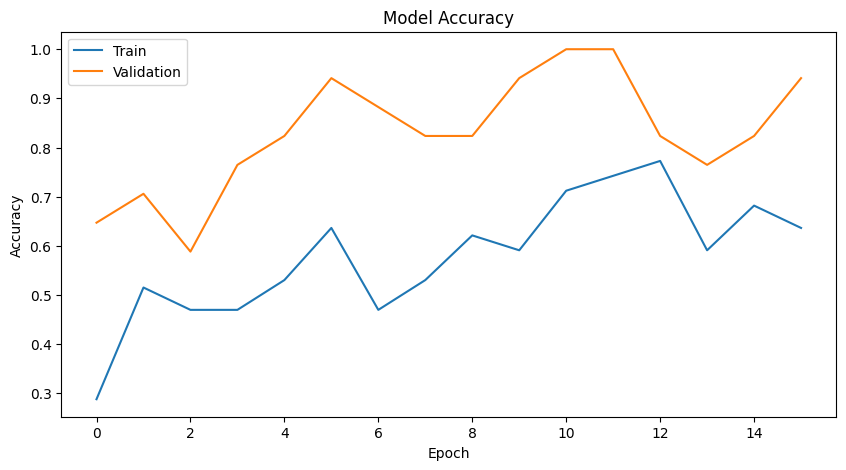

In [30]:
#step-accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

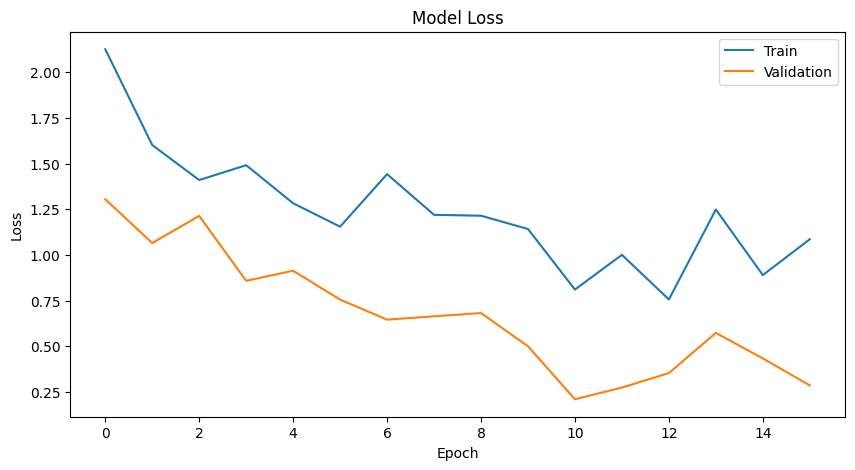

In [31]:
#step-loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [32]:
model.save("human_action_recognition_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [33]:
#prediction fuction
def predict_video(video_path):

    frames = extract_frames(video_path)

    frames = np.expand_dims(frames, axis=0)

    prediction = model.predict(frames)[0]

    predicted_class = CLASSES_LIST[np.argmax(prediction)]

    confidence = np.max(prediction)

    print(f"Predicted Action: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

In [37]:
# example test video

test_video = "/content/drive/MyDrive/ucf101_top5/Dataset/ShavingBeard/v_ShavingBeard_g12_c03.avi" # Example video from dataset

predict_video(test_video)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted Action: ShavingBeard
Confidence: 0.78
